# Preparing the Dataset for Emotion Analysis

In [2]:
import pandas as pd
from transformers import pipeline
from collections import Counter
import matplotlib.pyplot as plt

Import Dataset

In [3]:
#import chardet

#with open("dpdr_topics_sortiert.csv", "rb") as f:
#    raw_data = f.read(100000)  # sample
#    result = chardet.detect(raw_data)

df = pd.read_csv("dpdr_topics_sortiert.csv", encoding="utf-8", encoding_errors="replace")

In [4]:
print(df["document"].str.contains(r"Ã|â|�", na=False).sum())
#Okay some data in "document" is decoded incorrectly. Rewrite "document" column from "text" and "title" column again

0


In [5]:
#df["title"] = df["title"].fillna("")
#df["text"] = df["text"].fillna("")
#df["document"] = (df["title"] + " " + df["text"]).str.strip()

# remove empty rows
#df = df[df["document"] != ""]

In [6]:
print(df["document"].str.contains(r"Ã|â|�", na=False).sum())
#Okay, no falsely decoded data

0


# Emotion Analysis

In [7]:
# Load the emotion model
emotion_pipeline = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None,
    truncation=True,
    max_length=512
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Create a function for one text (Transformer models have input-length limits, so truncating is standard practice.)

In [8]:
# Due to error message: TypeError: string indices must be integers, not 'str'
def get_emotion_scores(text):
    results = emotion_pipeline(str(text))
    if isinstance(results[0], list):
        results = results[0]
    return {item["label"]: item["score"] for item in results}

In [9]:
test = emotion_pipeline(str(df["document"].iloc[0]))
print(type(test))
print(test)
#All emotions should be in the output, not just one

<class 'list'>
[[{'label': 'fear', 'score': 0.7844079732894897}, {'label': 'sadness', 'score': 0.11925705522298813}, {'label': 'neutral', 'score': 0.045697346329689026}, {'label': 'surprise', 'score': 0.02066490240395069}, {'label': 'joy', 'score': 0.016389572992920876}, {'label': 'anger', 'score': 0.008652549237012863}, {'label': 'disgust', 'score': 0.004930631257593632}]]


In [10]:
# Are there any empty rows that may make merging difficult?
df["document"].isna().sum(), (df["document"].astype(str).str.strip() == "").sum()

(np.int64(0), np.int64(0))

In [11]:
# Apply to all documents
emotion_scores = df["document"].apply(get_emotion_scores)
emotion_df = pd.DataFrame(emotion_scores.tolist())

In [12]:
# Merge results back into dataframe
df = pd.concat([df, emotion_df], axis=1)

In [13]:
# Used to avoid index alignment problems later on
df = df.reset_index(drop=True)

In [14]:
# Assign the dominant emotion
emotion_labels = emotion_df.columns.tolist()
df["dominant_emotion"] = df[emotion_labels].idxmax(axis=1)
df["dominant_emotion_score"] = df[emotion_labels].max(axis=1)

In [15]:
print(df[emotion_labels].isna().sum())  # Should all be 0
print(df[emotion_labels].head())        # Should show all 7 scores per row

fear        0
sadness     0
neutral     0
surprise    0
joy         0
anger       0
disgust     0
dtype: int64
       fear   sadness   neutral  surprise       joy     anger   disgust
0  0.784408  0.119257  0.045697  0.020665  0.016390  0.008653  0.004931
1  0.089500  0.061039  0.182853  0.558194  0.085877  0.012567  0.009970
2  0.978635  0.001948  0.003269  0.009683  0.004604  0.001505  0.000354
3  0.421646  0.021305  0.089545  0.439192  0.008722  0.008886  0.010704
4  0.108094  0.155622  0.448876  0.175850  0.002489  0.027904  0.081165


In [16]:
# Inspect results
print(df[["document", "dominant_emotion", "dominant_emotion_score"]].head())

                                            document dominant_emotion  \
0  Am I too inteligent for life or am i just copi...             fear   
1  Childhood depersonalization Im a 17 female Ive...         surprise   
2  Magnesium glycinate helped After reading so ma...             fear   
3  Dream-like state I think I'm experiencing it a...         surprise   
4  Difficulty To Process Information Properly? Hi...          neutral   

   dominant_emotion_score  
0                0.784408  
1                0.558194  
2                0.978635  
3                0.439192  
4                0.448876  


Overall Distribution (%)

In [17]:
# Overall distribution
emotion_distribution = df["dominant_emotion"].value_counts(normalize=True)
print(emotion_distribution)

dominant_emotion
fear        0.475054
sadness     0.186551
neutral     0.155098
surprise    0.084599
joy         0.045553
disgust     0.030369
anger       0.022777
Name: proportion, dtype: float64


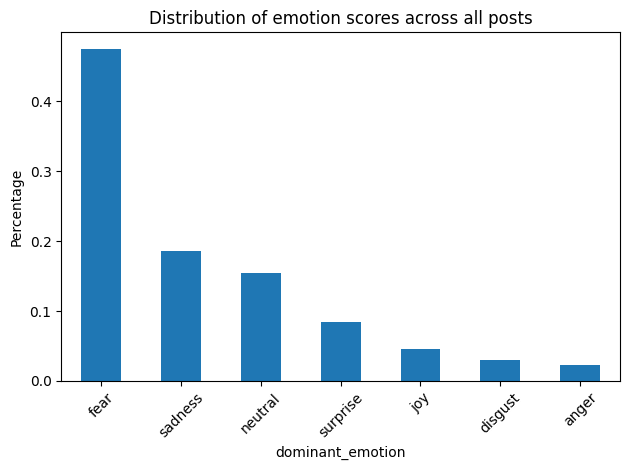

In [18]:
emotion_distribution.plot(kind="bar")
plt.ylabel("Percentage")
plt.title("Distribution of emotion scores across all posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average Emotion Scores

In [19]:
# Average score per emotion across the whole dataset
mean_emotion_scores = df[emotion_labels].mean().sort_values(ascending=False)
print(mean_emotion_scores)

fear        0.438064
sadness     0.188552
neutral     0.146772
surprise    0.102780
joy         0.044008
disgust     0.043541
anger       0.036282
dtype: float64


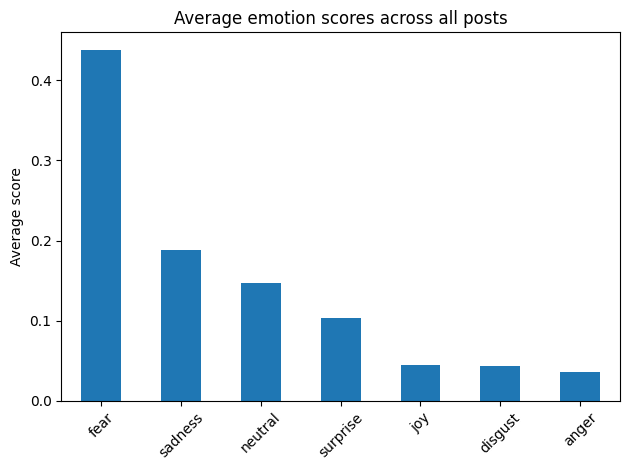

In [20]:
# Simple plot
mean_emotion_scores.plot(kind="bar")
plt.ylabel("Average score")
plt.title("Average emotion scores across all posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Put both into the same plot

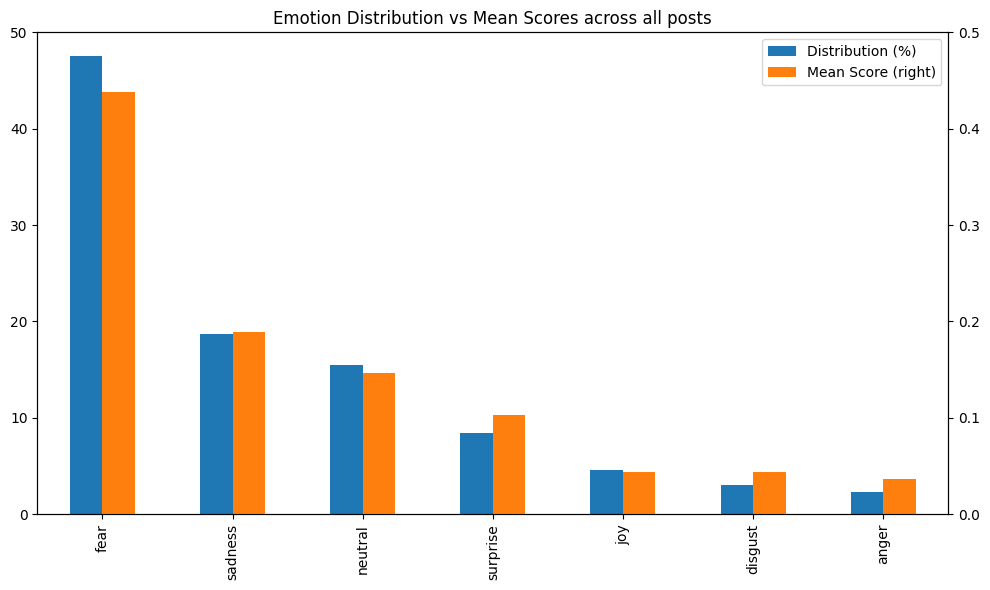

In [21]:
# Combine both into one dataframe
comparison_df = pd.DataFrame({
    "Distribution (%)": emotion_distribution * 100,
    "Mean Score": mean_emotion_scores
})

# Sort by distribution for consistency
comparison_df = comparison_df.sort_values("Distribution (%)", ascending=False)

# Plot
ax = comparison_df.plot(kind="bar", figsize=(10, 6), secondary_y="Mean Score")
plt.title("Emotion Distribution vs Mean Scores across all posts")
plt.xlabel("Emotion")
plt.xticks(rotation=45)
ax.right_ax.set_ylim(0,0.5)
ax.set_ylim(0,50)
plt.tight_layout()
plt.show()

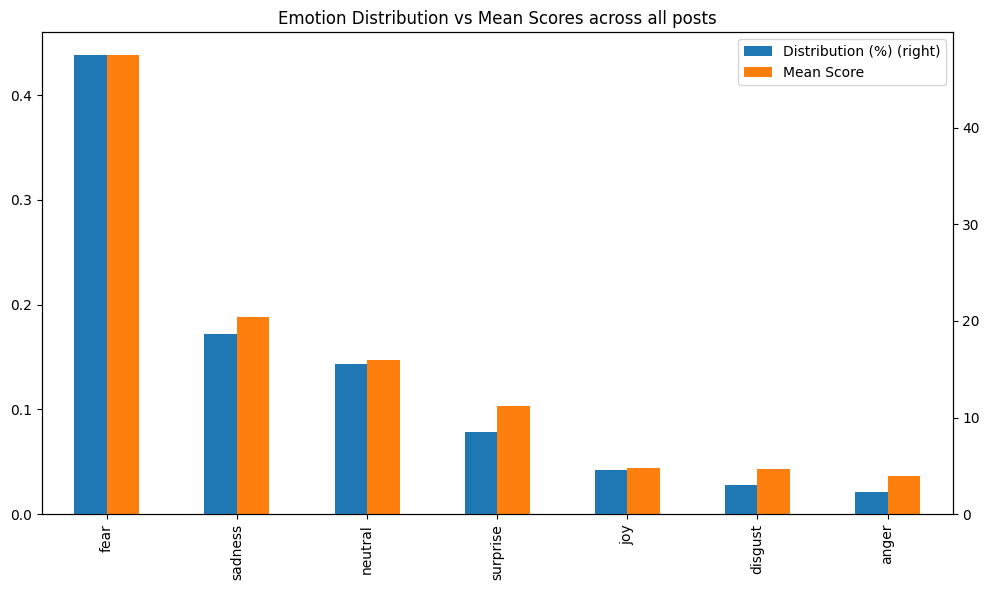

In [22]:
# Turn plot around

# Combine both into one dataframe
comparison_df = pd.DataFrame({
    "Distribution (%)": emotion_distribution * 100,
    "Mean Score": mean_emotion_scores
})

# Sort by distribution for consistency
comparison_df = comparison_df.sort_values("Mean Score", ascending=False)

# Plot
comparison_df.plot(kind="bar", figsize=(10, 6), secondary_y="Distribution (%)")
plt.title("Emotion Distribution vs Mean Scores across all posts")
plt.xlabel("Emotion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Which Types of Posts are Featured per Emotion?

In [23]:
for post in df[df["dominant_emotion"] == "neutral"]["document"].sample(10):
    print(post)
    print("\n" + "-"*100 + "\n")

Quitting Caffeine Helped Quitting caffeine is one of the things that helped me the most.When you consume caffeine, it reduces blood flow to the brain by nearly 40%, which can lead to the classic caffeine crash many people experience. Nobody wants a 40% reduction in blood flow that lasts for hours.Caffeine also has a half-life of about 6 hours and can take 2030 hours to fully leave the body, which means it will interfere with your sleep.When I quit caffeine, I noticed a huge improvement in my sleep. I fall asleep much faster and feel more refreshed the next day, which has helped me a lot with my anxiety.I can only recommend this to anyone.

----------------------------------------------------------------------------------------------------

ADHD meds helped After more than two years of coping with DPDR my psychiatrist tried me on methylphenidate. It was as if I was normal again as soon as the medication took effect. She switched me to vyvanse after some issues with the methylphenidate. 

In [24]:
# Save results
#df.to_csv("emotion_analysis_results.csv", index=False)

# Emotion Analysis per Topic

Prepare the Data

In [25]:
# Load the Dataset
#df_topics = pd.read_csv("dpdr_topics.csv")

# Does Decoding work?
#print(df_topics["document"].str.contains(r"Ã|â|�", na=False).sum())

In [26]:
#Merge the Data
#merged_df = df_topics.merge(df, on="timestamp", how="left")
merged_df=df

In [27]:
# See if merging worked as expected
#print(f"Total rows: {len(merged_df)}")
#print(f"Unmatched rows: {merged_df['dominant_emotion'].isna().sum()}")

In [28]:
merged_df.head(2)

,Unnamed: 0,date_utc,timestamp,title,text,subreddit,comments,url,document,word_count,...,probs,fear,sadness,neutral,surprise,joy,anger,disgust,dominant_emotion,dominant_emotion_score
0,1,2025-12-14,1765741825,Am I too inteligent for life or am i just coping?,"'ve constructed a fake world in my mind, the r...",dpdr,1,https://www.reddit.com/r/dpdr/comments/1pmn69k...,Am I too inteligent for life or am i just copi...,175,...,0.291049,0.784408,0.119257,0.045697,0.020665,0.016390,0.008653,0.004931,fear,0.784408
1,2,2025-12-14,1765734691,Childhood depersonalization,Im a 17 female Ive had depersonalization for 1...,dpdr,5,https://www.reddit.com/r/dpdr/comments/1pmk8s1...,Childhood depersonalization Im a 17 female Ive...,64,...,0.104179,0.089500,0.061039,0.182853,0.558194,0.085877,0.012567,0.009970,surprise,0.558194


How to Visualise?

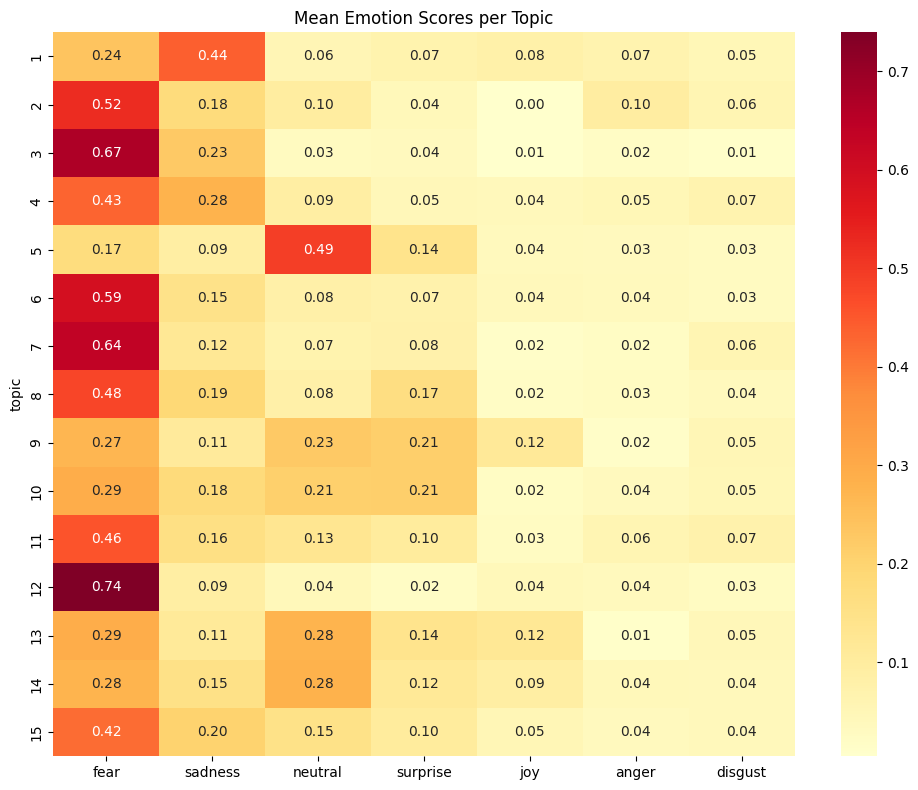

In [29]:
# Try heatmap

import seaborn as sns
#Exclude outlier topic
topic_emotion = merged_df[merged_df["topic"] != -1].groupby("topic")[emotion_labels].mean()


#Build Topic X Emotion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(topic_emotion, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Mean Emotion Scores per Topic")
plt.tight_layout()
plt.show()

In [30]:
topic_emotion

,fear,sadness,neutral,surprise,joy,anger,disgust
topic,,,,,,,
1,0.239697,0.440379,0.055358,0.069961,0.078626,0.066381,0.049597
2,0.522828,0.176500,0.096940,0.044572,0.004552,0.096332,0.058276
3,0.669818,0.225834,0.031573,0.035497,0.005294,0.019098,0.012886
4,0.430511,0.277938,0.091649,0.046136,0.039833,0.048123,0.065810
5,0.172545,0.092051,0.492102,0.141140,0.038340,0.033643,0.030179
6,0.593648,0.147835,0.080188,0.072426,0.040060,0.036176,0.029668
7,0.637303,0.120726,0.069003,0.076096,0.015127,0.023055,0.058690
8,0.479437,0.190601,0.080000,0.165064,0.021391,0.025194,0.038314
9,0.270079,0.108514,0.226146,0.212730,0.115820,0.015628,0.051083


In [31]:
# Let's take a closer look
topic_posts = merged_df[(merged_df["topic"] == 7) & (merged_df["dominant_emotion"] == "fear")]["document"]

for post in topic_posts.sample(min(10, len(topic_posts))):
    print(post)
    print("\n" + "-"*100 + "\n")

16 years of DPDR, relapse, and just wanting my life back Ive had DPDR on and off for around 16 years. It originally started after a bad weed experience. Around that time and for many years after, I was drinking alcohol heavily. When I drank, it actually made me feel calm, at peace, and more normal, which is probably why I relied on it so much. I didnt know what DPDR was, never went to the doctors, never told anyone, and never researched it. I just got used to the feelings and lived a mostly normal life.That said, I was always terrified of going to new places. I refused to leave the country and avoided learning to drive because I was scared the feelings would come back. I accepted that Id be fine as long as I never went abroad (which I know sounds strange).Fast forward about 10 years. I eventually pushed myself to learn to drive and passed first time. Driving became no issue at all. I loved it and drove everywhere.About 4 years later, I couldnt hide from my girlfriend anymore why I woul

In [32]:
# Why are some cells black?
print(merged_df.groupby("topic")[emotion_labels].count())
# Some topics have 0 counts for a specific emotion

       fear  sadness  neutral  surprise  joy  anger  disgust
topic                                                       
1        38       38       38        38   38     38       38
2        34       34       34        34   34     34       34
3        84       84       84        84   84     84       84
4        60       60       60        60   60     60       60
5        50       50       50        50   50     50       50
6        19       19       19        19   19     19       19
7        87       87       87        87   87     87       87
8        60       60       60        60   60     60       60
9        46       46       46        46   46     46       46
10       35       35       35        35   35     35       35
11       45       45       45        45   45     45       45
12       14       14       14        14   14     14       14
13       27       27       27        27   27     27       27
14       40       40       40        40   40     40       40
15      283      283    

In [33]:
print(merged_df[emotion_labels].isna().sum())
print(merged_df[emotion_labels].head())        # Should show all 7 scores per row

fear        0
sadness     0
neutral     0
surprise    0
joy         0
anger       0
disgust     0
dtype: int64
       fear   sadness   neutral  surprise       joy     anger   disgust
0  0.784408  0.119257  0.045697  0.020665  0.016390  0.008653  0.004931
1  0.089500  0.061039  0.182853  0.558194  0.085877  0.012567  0.009970
2  0.978635  0.001948  0.003269  0.009683  0.004604  0.001505  0.000354
3  0.421646  0.021305  0.089545  0.439192  0.008722  0.008886  0.010704
4  0.108094  0.155622  0.448876  0.175850  0.002489  0.027904  0.081165


In [34]:
# Topic Distribution (percent values) -> Are the topics in the correct order?
topic_emotion_distribution = pd.crosstab(
    merged_df["topic"],
    merged_df["dominant_emotion"],
    normalize="index"
) * 100

topic_emotion_distribution = topic_emotion_distribution.reset_index()

topic_emotion_distribution

dominant_emotion,topic,anger,disgust,fear,joy,neutral,sadness,surprise
0,1,5.263158,2.631579,26.315789,7.894737,2.631579,47.368421,7.894737
1,2,11.764706,5.882353,55.882353,0.000000,8.823529,14.705882,2.941176
2,3,1.190476,0.000000,70.238095,0.000000,2.380952,23.809524,2.380952
3,4,1.666667,5.000000,51.666667,1.666667,10.000000,28.333333,1.666667
4,5,2.000000,2.000000,16.000000,2.000000,64.000000,6.000000,8.000000
5,6,5.263158,0.000000,57.894737,5.263158,10.526316,15.789474,5.263158
6,7,1.149425,4.597701,72.413793,1.149425,4.597701,11.494253,4.597701
7,8,0.000000,1.666667,53.333333,1.666667,10.000000,21.666667,11.666667
8,9,0.000000,6.521739,26.086957,13.043478,19.565217,10.869565,23.913043
9,10,2.857143,0.000000,25.714286,2.857143,22.857143,17.142857,28.571429
